<a href="https://colab.research.google.com/github/sudhans18/ABDA/blob/main/03_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/cmu_mosei"

READY_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_ready_v2.pkl"
)

SENTIMENT_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_features.pkl"
)

METADATA_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_features_metadata.json"
)

print("Input:")
print(READY_PATH)

print("\nOutput:")
print(SENTIMENT_PATH)

Input:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.pkl

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl


In [ ]:
df = pd.read_pickle(READY_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (23253, 13)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear']


In [ ]:
assert "sentiment" in df.columns

print(df["sentiment"].describe())

count    23253.000000
mean         0.151479
std          1.111496
min         -3.000000
25%         -0.333333
50%          0.000000
75%          1.000000
max          3.000000
Name: sentiment, dtype: float64


In [ ]:
print("Missing sentiment:", df["sentiment"].isna().sum())

print(
    "Values below -3:",
    (df["sentiment"] < -3).sum()
)

print(
    "Values above +3:",
    (df["sentiment"] > 3).sum()
)

Missing sentiment: 0
Values below -3: 0
Values above +3: 0


In [ ]:
assert df["sentiment"].notna().all()
assert (df["sentiment"] >= -3).all()
assert (df["sentiment"] <= 3).all()

print("Sentiment range validation passed.")

Sentiment range validation passed.


In [ ]:
unique_sentiments = sorted(df["sentiment"].unique())

print("Number of unique sentiment values:", len(unique_sentiments))
print("\nUnique values:")
print(unique_sentiments)

Number of unique sentiment values: 28

Unique values:
[np.float64(-3.0), np.float64(-2.6666667461395264), np.float64(-2.3333332538604736), np.float64(-2.0), np.float64(-1.6666666269302368), np.float64(-1.3333333730697632), np.float64(-1.0), np.float64(-0.6666666865348816), np.float64(-0.5), np.float64(-0.3333333432674408), np.float64(-0.1666666716337204), np.float64(0.0), np.float64(0.1666666716337204), np.float64(0.3333333432674408), np.float64(0.5), np.float64(0.6666666865348816), np.float64(0.8333333134651184), np.float64(1.0), np.float64(1.1666666269302368), np.float64(1.3333333730697632), np.float64(1.5), np.float64(1.6666666269302368), np.float64(1.8333333730697632), np.float64(2.0), np.float64(2.3333332538604736), np.float64(2.5), np.float64(2.6666667461395264), np.float64(3.0)]


In [ ]:
sentiment_counts = (
    df["sentiment"]
    .value_counts()
    .sort_index()
)

print(sentiment_counts)

sentiment
-3.000000     126
-2.666667     282
-2.333333     413
-2.000000     651
-1.666667     765
-1.333333     836
-1.000000     904
-0.666667    1129
-0.500000       4
-0.333333    1569
-0.166667       3
 0.000000    5100
 0.166667      11
 0.333333    3059
 0.500000      11
 0.666667    2563
 0.833333       7
 1.000000    1921
 1.166667       3
 1.333333    1432
 1.500000       8
 1.666667    1033
 1.833333       2
 2.000000     746
 2.333333     405
 2.500000       1
 2.666667     208
 3.000000      61
Name: count, dtype: int64


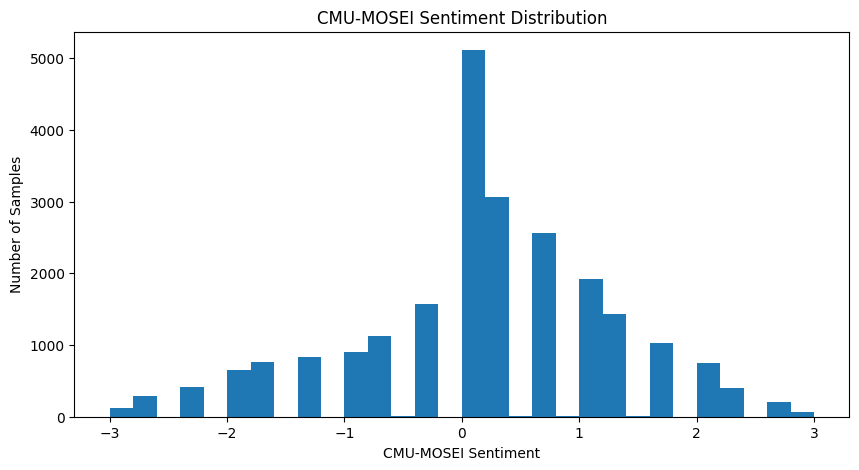

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["sentiment"],
    bins=30
)

plt.xlabel("CMU-MOSEI Sentiment")
plt.ylabel("Number of Samples")
plt.title("CMU-MOSEI Sentiment Distribution")

plt.show()

In [ ]:
df["sentiment_normalized"] = df["sentiment"] / 3.0

print(
    df["sentiment_normalized"].describe()
)

count    23253.000000
mean         0.050493
std          0.370499
min         -1.000000
25%         -0.111111
50%          0.000000
75%          0.333333
max          1.000000
Name: sentiment_normalized, dtype: float64


In [ ]:
print(
    "Minimum:",
    df["sentiment_normalized"].min()
)

print(
    "Maximum:",
    df["sentiment_normalized"].max()
)

assert df["sentiment_normalized"].min() >= -1
assert df["sentiment_normalized"].max() <= 1

print("Normalization validation passed.")

Minimum: -1.0
Maximum: 1.0
Normalization validation passed.


In [ ]:
def sentiment_polarity(value):
    if value < 0:
        return "negative"
    elif value > 0:
        return "positive"
    else:
        return "neutral"


df["sentiment_polarity"] = (
    df["sentiment"]
    .apply(sentiment_polarity)
)

print(df["sentiment_polarity"].value_counts())

sentiment_polarity
positive    11471
negative     6682
neutral      5100
Name: count, dtype: int64


In [ ]:
polarity_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

df["sentiment_polarity_numeric"] = (
    df["sentiment_polarity"]
    .map(polarity_map)
)

print(
    df["sentiment_polarity_numeric"].value_counts()
    .sort_index()
)

sentiment_polarity_numeric
-1     6682
 0     5100
 1    11471
Name: count, dtype: int64


In [ ]:
display(
    df[
        [
            "text",
            "sentiment",
            "sentiment_normalized",
            "sentiment_polarity",
            "sentiment_polarity_numeric"
        ]
    ].head(20)
)

,text,sentiment,sentiment_normalized,sentiment_polarity,sentiment_polarity_numeric
0,writer i see that a writer is somebody who has...,1.000000,0.333333,positive,1
1,key is part of the people that we use to solve...,1.000000,0.333333,positive,1
2,businesses that we do they've been able to fin...,0.666667,0.222222,positive,1
3,operations key polymer brings a technical aspe...,0.000000,0.000000,neutral,0
4,internally we're a huge user of adhesives for ...,0.000000,0.000000,neutral,0
5,of things key brings those types of aspects to...,1.000000,0.333333,positive,1
6,solutions we have many new opportunities throu...,0.666667,0.222222,positive,1
7,introduction speaker dr erma jean sims sonoma ...,0.333333,0.111111,positive,1
8,it's important for teachers to understand thei...,1.000000,0.333333,positive,1
9,noncompliance can result in legal liability to...,0.000000,0.000000,neutral,0


In [ ]:
sentiment_stats = {
    "count": int(df["sentiment"].count()),
    "mean": float(df["sentiment"].mean()),
    "std": float(df["sentiment"].std()),
    "min": float(df["sentiment"].min()),
    "max": float(df["sentiment"].max()),
    "median": float(df["sentiment"].median())
}

print(json.dumps(sentiment_stats, indent=4))

{
    "count": 23253,
    "mean": 0.15147866444224128,
    "std": 1.1114957846448181,
    "min": -3.0,
    "max": 3.0,
    "median": 0.0
}


In [ ]:
polarity_percentages = (
    df["sentiment_polarity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

print(polarity_percentages)

sentiment_polarity
positive    49.331
negative    28.736
neutral     21.933
Name: proportion, dtype: float64


In [ ]:
print(
    df[
        ["token_count", "sentiment"]
    ].corr()
)

             token_count  sentiment
token_count     1.000000   0.040255
sentiment       0.040255   1.000000


In [ ]:
sentiment_df = df.copy()

print("Shape:", sentiment_df.shape)

Shape: (23253, 16)


In [ ]:
sentiment_columns = [
    "sentiment",
    "sentiment_normalized",
    "sentiment_polarity",
    "sentiment_polarity_numeric"
]

print("Sentiment feature columns:")

for col in sentiment_columns:
    print("-", col)

Sentiment feature columns:
- sentiment
- sentiment_normalized
- sentiment_polarity
- sentiment_polarity_numeric


In [ ]:
for col in sentiment_columns:
    print(
        col,
        "missing:",
        sentiment_df[col].isna().sum()
    )

sentiment missing: 0
sentiment_normalized missing: 0
sentiment_polarity missing: 0
sentiment_polarity_numeric missing: 0


In [ ]:
assert sentiment_df["sentiment_normalized"].notna().all()
assert sentiment_df["sentiment_polarity_numeric"].notna().all()

print("Sentiment feature validation passed.")

Sentiment feature validation passed.


In [ ]:
sentiment_df.to_pickle(SENTIMENT_PATH)

print("Saved successfully:")
print(SENTIMENT_PATH)

Saved successfully:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl


In [ ]:
reloaded_sentiment_df = pd.read_pickle(
    SENTIMENT_PATH
)

print(
    "Reloaded shape:",
    reloaded_sentiment_df.shape
)

print(
    "Columns:",
    reloaded_sentiment_df.columns.tolist()
)

Reloaded shape: (23253, 16)
Columns: ['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear', 'sentiment_normalized', 'sentiment_polarity', 'sentiment_polarity_numeric']


In [ ]:
assert reloaded_sentiment_df.shape == sentiment_df.shape

assert (
    reloaded_sentiment_df["sentiment"]
    .equals(sentiment_df["sentiment"])
)

assert (
    reloaded_sentiment_df["sentiment_normalized"]
    .equals(sentiment_df["sentiment_normalized"])
)

assert (
    reloaded_sentiment_df["sentiment_polarity"]
    .equals(sentiment_df["sentiment_polarity"])
)

print("Reload integrity check PASSED.")

Reload integrity check PASSED.


In [ ]:
metadata = {
    "dataset": "CMU-MOSEI",
    "feature_group": "Sentiment",
    "source": "CMU-MOSEI provided sentiment annotation",
    "original_sentiment_range": [-3, 3],
    "normalized_sentiment_range": [-1, 1],
    "normalization_formula": "sentiment / 3.0",
    "polarity_definition": {
        "negative": "< 0",
        "neutral": "= 0",
        "positive": "> 0"
    },
    "number_of_samples": int(len(sentiment_df)),
    "input_file": os.path.basename(READY_PATH),
    "output_file": os.path.basename(SENTIMENT_PATH)
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features_metadata.json


In [ ]:
print("=" * 60)
print("CMU-MOSEI SENTIMENT FEATURE PIPELINE COMPLETE")
print("=" * 60)

print("Samples:", len(sentiment_df))

print(
    "Original sentiment range:",
    sentiment_df["sentiment"].min(),
    "to",
    sentiment_df["sentiment"].max()
)

print(
    "Normalized range:",
    sentiment_df["sentiment_normalized"].min(),
    "to",
    sentiment_df["sentiment_normalized"].max()
)

print("\nPolarity distribution:")
print(sentiment_df["sentiment_polarity"].value_counts())

print("\nOutput:")
print(SENTIMENT_PATH)

print("\nMetadata:")
print(METADATA_PATH)

CMU-MOSEI SENTIMENT FEATURE PIPELINE COMPLETE
Samples: 23253
Original sentiment range: -3.0 to 3.0
Normalized range: -1.0 to 1.0

Polarity distribution:
sentiment_polarity
positive    11471
negative     6682
neutral      5100
Name: count, dtype: int64

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl

Metadata:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features_metadata.json


# Pretrained Sentiment Models

In [1]:
!pip install -q transformers accelerate scipy scikit-learn

In [2]:
import os
import json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [4]:
PROJECT_DIR = "/content/drive/MyDrive/cmu_mosei"

GROUND_TRUTH_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_features.pkl"
)

sentiment_df = pd.read_pickle(GROUND_TRUTH_PATH)

print("Shape:", sentiment_df.shape)
print("\nColumns:")
print(sentiment_df.columns.tolist())

Shape: (23253, 16)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear', 'sentiment_normalized', 'sentiment_polarity', 'sentiment_polarity_numeric']


In [5]:
assert "text" in sentiment_df.columns
assert "sentiment" in sentiment_df.columns
assert "sentiment_normalized" in sentiment_df.columns

assert sentiment_df["text"].notna().all()
assert sentiment_df["sentiment"].notna().all()

print("Samples:", len(sentiment_df))
print("Missing text:", sentiment_df["text"].isna().sum())
print("Missing sentiment:", sentiment_df["sentiment"].isna().sum())

Samples: 23253
Missing text: 0
Missing sentiment: 0


In [6]:
texts = sentiment_df["text"].tolist()

y_true_continuous = (
    sentiment_df["sentiment_normalized"]
    .astype(float)
    .to_numpy()
)

print("Number of texts:", len(texts))
print("Ground-truth range:",
      y_true_continuous.min(),
      "to",
      y_true_continuous.max())

Number of texts: 23253
Ground-truth range: -1.0 to 1.0


In [7]:
def load_sentiment_model(model_name):
    print("=" * 70)
    print("Loading:", model_name)
    print("=" * 70)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name
    )

    model.to(device)
    model.eval()

    print("Model loaded.")
    print("Labels:", model.config.id2label)
    print(
        "Max position embeddings:",
        getattr(model.config, "max_position_embeddings", "unknown")
    )

    return tokenizer, model

In [8]:
def predict_sentiment(
    texts,
    model_name,
    batch_size=32
):

    tokenizer, model = load_sentiment_model(model_name)

    results = []

    # Determine a practical model input limit
    model_max_length = getattr(
        model.config,
        "max_position_embeddings",
        None
    )

    if model_max_length is None:
        model_max_length = 512

    print("Using max input length:", model_max_length)

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[
            start:start + batch_size
        ]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=model_max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():

            outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

        results.append(
            probabilities.cpu().numpy()
        )

        if (
            start == 0
            or (start + batch_size) % (batch_size * 10) == 0
            or start + batch_size >= len(texts)
        ):
            print(
                f"Processed {min(start + batch_size, len(texts))}"
                f" / {len(texts)}"
            )

    probabilities = np.vstack(results)

    id2label = model.config.id2label

    return probabilities, id2label

In [9]:
TEST_MODEL = "siebert/sentiment-roberta-large-english"

test_tokenizer = AutoTokenizer.from_pretrained(
    TEST_MODEL
)

test_model = AutoModelForSequenceClassification.from_pretrained(
    TEST_MODEL
)

print(test_model.config.id2label)

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.42GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

{0: 'NEGATIVE', 1: 'POSITIVE'}


In [10]:
test_texts = texts[:5]

encoded = test_tokenizer(
    test_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = test_model(**encoded)

probs = torch.softmax(
    outputs.logits,
    dim=-1
)

print("Probability shape:", probs.shape)
print(probs)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Probability shape: torch.Size([5, 2])
tensor([[0.0033, 0.9967],
        [0.0011, 0.9989],
        [0.0012, 0.9988],
        [0.0014, 0.9986],
        [0.9957, 0.0043]])


## Run Model 1: SiEBERT

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SIEBERT_MODEL = (
    "siebert/sentiment-roberta-large-english"
)

siebert_probs, siebert_labels = predict_sentiment(
    texts,
    SIEBERT_MODEL,
    batch_size=16
)

print("\nProbability matrix shape:")
print(siebert_probs.shape)

print("\nLabels:")
print(siebert_labels)

Loading: siebert/sentiment-roberta-large-english


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Model loaded.
Labels: {0: 'NEGATIVE', 1: 'POSITIVE'}
Max position embeddings: 514
Using max input length: 514
Processed 16 / 23253
Processed 160 / 23253
Processed 320 / 23253
Processed 480 / 23253
Processed 640 / 23253
Processed 800 / 23253
Processed 960 / 23253
Processed 1120 / 23253
Processed 1280 / 23253
Processed 1440 / 23253
Processed 1600 / 23253
Processed 1760 / 23253
Processed 1920 / 23253
Processed 2080 / 23253
Processed 2240 / 23253
Processed 2400 / 23253
Processed 2560 / 23253
Processed 2720 / 23253
Processed 2880 / 23253
Processed 3040 / 23253
Processed 3200 / 23253
Processed 3360 / 23253
Processed 3520 / 23253
Processed 3680 / 23253
Processed 3840 / 23253
Processed 4000 / 23253
Processed 4160 / 23253
Processed 4320 / 23253
Processed 4480 / 23253
Processed 4640 / 23253
Processed 4800 / 23253
Processed 4960 / 23253
Processed 5120 / 23253
Processed 5280 / 23253
Processed 5440 / 23253
Processed 5600 / 23253
Processed 5760 / 23253
Processed 5920 / 23253
Processed 6080 / 23253
P

In [13]:
def continuous_sentiment_from_probs(
    probabilities,
    id2label
):

    positive_idx = None
    negative_idx = None

    for idx, label in id2label.items():

        label_lower = label.lower()

        if "positive" in label_lower:
            positive_idx = int(idx)

        elif "negative" in label_lower:
            negative_idx = int(idx)

    if positive_idx is None or negative_idx is None:
        raise ValueError(
            f"Could not identify positive/negative labels: {id2label}"
        )

    score = (
        probabilities[:, positive_idx]
        - probabilities[:, negative_idx]
    )

    return score

In [15]:
siebert_score = continuous_sentiment_from_probs(
    siebert_probs,
    siebert_labels
)

print("Min:", siebert_score.min())
print("Max:", siebert_score.max())
print("Mean:", siebert_score.mean())

Min: -0.99903417
Max: 0.9978753
Mean: 0.19318235


## Test Model 2: Cardiff XLM-R

In [16]:
CARDIFF_XLM_MODEL = (
    "cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

cardiff_probs, cardiff_labels = predict_sentiment(
    texts,
    CARDIFF_XLM_MODEL,
    batch_size=32
)

print("\nProbability matrix shape:")
print(cardiff_probs.shape)

print("\nLabels:")
print(cardiff_labels)

Loading: cardiffnlp/twitter-xlm-roberta-base-sentiment


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.
Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
Max position embeddings: 514
Using max input length: 514
Processed 32 / 23253


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Processed 320 / 23253
Processed 640 / 23253
Processed 960 / 23253
Processed 1280 / 23253
Processed 1600 / 23253
Processed 1920 / 23253
Processed 2240 / 23253
Processed 2560 / 23253
Processed 2880 / 23253
Processed 3200 / 23253
Processed 3520 / 23253
Processed 3840 / 23253
Processed 4160 / 23253
Processed 4480 / 23253
Processed 4800 / 23253
Processed 5120 / 23253
Processed 5440 / 23253
Processed 5760 / 23253
Processed 6080 / 23253
Processed 6400 / 23253
Processed 6720 / 23253
Processed 7040 / 23253
Processed 7360 / 23253
Processed 7680 / 23253
Processed 8000 / 23253
Processed 8320 / 23253
Processed 8640 / 23253
Processed 8960 / 23253
Processed 9280 / 23253
Processed 9600 / 23253
Processed 9920 / 23253
Processed 10240 / 23253
Processed 10560 / 23253
Processed 10880 / 23253
Processed 11200 / 23253
Processed 11520 / 23253
Processed 11840 / 23253
Processed 12160 / 23253
Processed 12480 / 23253
Processed 12800 / 23253
Processed 13120 / 23253
Processed 13440 / 23253
Processed 13760 / 23253
Pr

In [17]:
cardiff_score = continuous_sentiment_from_probs(
    cardiff_probs,
    cardiff_labels
)

print("Min:", cardiff_score.min())
print("Max:", cardiff_score.max())
print("Mean:", cardiff_score.mean())

Min: -0.956752
Max: 0.9325647
Mean: -0.07154581


## Test Model 3: Multilingual DistilBERT

In [18]:
DISTIL_MODEL = (
    "lxyuan/"
    "distilbert-base-multilingual-cased-sentiments-student"
)

distil_probs, distil_labels = predict_sentiment(
    texts,
    DISTIL_MODEL,
    batch_size=32
)

print("\nProbability matrix shape:")
print(distil_probs.shape)

print("\nLabels:")
print(distil_labels)

Loading: lxyuan/distilbert-base-multilingual-cased-sentiments-student


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded.
Labels: {0: 'positive', 1: 'neutral', 2: 'negative'}
Max position embeddings: 512
Using max input length: 512
Processed 32 / 23253
Processed 320 / 23253
Processed 640 / 23253
Processed 960 / 23253
Processed 1280 / 23253
Processed 1600 / 23253
Processed 1920 / 23253
Processed 2240 / 23253
Processed 2560 / 23253
Processed 2880 / 23253
Processed 3200 / 23253
Processed 3520 / 23253
Processed 3840 / 23253
Processed 4160 / 23253
Processed 4480 / 23253
Processed 4800 / 23253
Processed 5120 / 23253
Processed 5440 / 23253
Processed 5760 / 23253
Processed 6080 / 23253
Processed 6400 / 23253
Processed 6720 / 23253
Processed 7040 / 23253
Processed 7360 / 23253
Processed 7680 / 23253
Processed 8000 / 23253
Processed 8320 / 23253
Processed 8640 / 23253
Processed 8960 / 23253
Processed 9280 / 23253
Processed 9600 / 23253
Processed 9920 / 23253
Processed 10240 / 23253
Processed 10560 / 23253
Processed 10880 / 23253
Processed 11200 / 23253
Processed 11520 / 23253
Processed 11840 / 23253
P

In [19]:
distil_score = continuous_sentiment_from_probs(
    distil_probs,
    distil_labels
)

print("Min:", distil_score.min())
print("Max:", distil_score.max())
print("Mean:", distil_score.mean())

Min: -0.9766961
Max: 0.9857402
Mean: 0.03627386


In [39]:
cm_cardiff = confusion_matrix(
    y_true_polarity,
    cardiff_polarity,
    labels=[0, 1, 2]
)

print(cm_cardiff)

[[4708 1592  382]
 [1125 3554  421]
 [1154 6167 4150]]


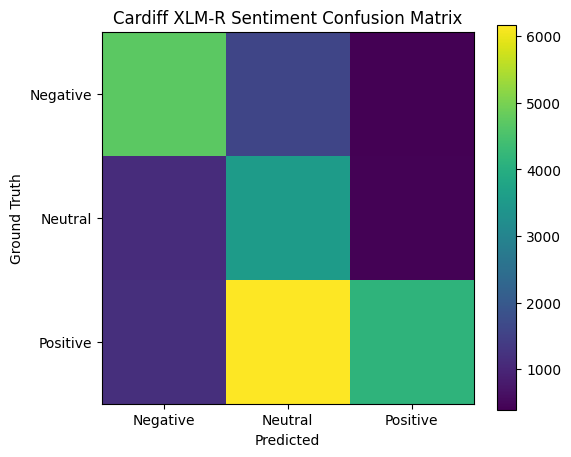

In [40]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_cardiff)

plt.xticks(
    [0, 1, 2],
    ["Negative", "Neutral", "Positive"]
)

plt.yticks(
    [0, 1, 2],
    ["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

plt.title(
    "Cardiff XLM-R Sentiment Confusion Matrix"
)

plt.colorbar()

plt.show()

In [20]:
prediction_preview = pd.DataFrame({
    "text": texts[:20],
    "ground_truth": y_true_continuous[:20],
    "siebert": siebert_score[:20],
    "cardiff_xlm": cardiff_score[:20],
    "distilbert": distil_score[:20]
})

display(prediction_preview)

,text,ground_truth,siebert,cardiff_xlm,distilbert
0,writer i see that a writer is somebody who has...,0.333333,0.993449,0.503507,0.027094
1,key is part of the people that we use to solve...,0.333333,0.997716,0.010070,0.145114
2,businesses that we do they've been able to fin...,0.222222,0.997526,0.148933,0.189879
3,operations key polymer brings a technical aspe...,0.000000,0.997233,0.099056,0.145340
4,internally we're a huge user of adhesives for ...,0.000000,-0.991327,-0.417819,-0.382588
5,of things key brings those types of aspects to...,0.333333,0.997361,0.368026,0.745477
6,solutions we have many new opportunities throu...,0.222222,0.997100,0.599200,0.575107
7,introduction speaker dr erma jean sims sonoma ...,0.111111,0.991130,0.105040,0.299080
8,it's important for teachers to understand thei...,0.333333,0.996738,0.123504,0.821896
9,noncompliance can result in legal liability to...,0.000000,-0.996499,-0.830041,0.023172


In [21]:
def evaluate_continuous_sentiment(
    y_true,
    y_pred
):

    pearson_r, pearson_p = pearsonr(
        y_true,
        y_pred
    )

    spearman_r, spearman_p = spearmanr(
        y_true,
        y_pred
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return {
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p,
        "MAE": mae,
        "RMSE": rmse
    }

In [22]:
continuous_results = {

    "SiEBERT": evaluate_continuous_sentiment(
        y_true_continuous,
        siebert_score
    ),

    "Cardiff_XLMR": evaluate_continuous_sentiment(
        y_true_continuous,
        cardiff_score
    ),

    "Multilingual_DistilBERT": evaluate_continuous_sentiment(
        y_true_continuous,
        distil_score
    )
}

continuous_results_df = pd.DataFrame(
    continuous_results
).T

display(
    continuous_results_df
)

,Pearson_r,Pearson_p,Spearman_r,Spearman_p,MAE,RMSE
SiEBERT,0.543505,0.0,0.654322,0.0,0.778914,0.838083
Cardiff_XLMR,0.662239,0.0,0.653224,0.0,0.292540,0.381631
Multilingual_DistilBERT,0.525766,0.0,0.514794,0.0,0.306035,0.391622


In [23]:
y_true_polarity = np.select(
    [
        y_true_continuous < 0,
        y_true_continuous == 0,
        y_true_continuous > 0
    ],
    [
        0,
        1,
        2
    ]
)

print(
    pd.Series(y_true_polarity)
    .value_counts()
    .sort_index()
)

0     6682
1     5100
2    11471
Name: count, dtype: int64


In [24]:
def polarity_predictions(
    probabilities,
    id2label
):

    predictions = []

    for row in probabilities:

        predicted_index = int(
            np.argmax(row)
        )

        label = id2label[predicted_index].lower()

        if "negative" in label:
            polarity = 0

        elif "neutral" in label:
            polarity = 1

        elif "positive" in label:
            polarity = 2

        else:
            raise ValueError(
                f"Unknown sentiment label: {label}"
            )

        predictions.append(polarity)

    return np.array(predictions)

In [25]:
siebert_polarity = polarity_predictions(
    siebert_probs,
    siebert_labels
)

cardiff_polarity = polarity_predictions(
    cardiff_probs,
    cardiff_labels
)

distil_polarity = polarity_predictions(
    distil_probs,
    distil_labels
)

In [26]:
binary_mask = y_true_continuous != 0

y_true_binary = (
    y_true_continuous[binary_mask] > 0
).astype(int)

siebert_binary = (
    siebert_score[binary_mask] > 0
).astype(int)

print(
    "Binary evaluation samples:",
    binary_mask.sum()
)

Binary evaluation samples: 18153


In [27]:
siebert_accuracy = accuracy_score(
    y_true_binary,
    siebert_binary
)

siebert_f1 = f1_score(
    y_true_binary,
    siebert_binary,
    average="macro"
)

print("SiEBERT accuracy:", siebert_accuracy)
print("SiEBERT macro-F1:", siebert_f1)

SiEBERT accuracy: 0.8063130061146918
SiEBERT macro-F1: 0.795831865071962


In [28]:
cardiff_accuracy = accuracy_score(
    y_true_polarity,
    cardiff_polarity
)

cardiff_f1 = f1_score(
    y_true_polarity,
    cardiff_polarity,
    average="macro"
)

print("Cardiff XLM-R accuracy:", cardiff_accuracy)
print("Cardiff XLM-R macro-F1:", cardiff_f1)

Cardiff XLM-R accuracy: 0.5337805874510816
Cardiff XLM-R macro-F1: 0.542429119467479


In [29]:
distil_accuracy = accuracy_score(
    y_true_polarity,
    distil_polarity
)

distil_f1 = f1_score(
    y_true_polarity,
    distil_polarity,
    average="macro"
)

print("Multilingual DistilBERT accuracy:", distil_accuracy)
print("Multilingual DistilBERT macro-F1:", distil_f1)

Multilingual DistilBERT accuracy: 0.5483163462778996
Multilingual DistilBERT macro-F1: 0.44174569590996793


## Final Comparison Table

In [30]:
comparison_rows = [
    {
        "Model": "SiEBERT",
        "Language_Type": "English",
        "Continuous_Pearson": continuous_results_df.loc[
            "SiEBERT", "Pearson_r"
        ],
        "Continuous_Spearman": continuous_results_df.loc[
            "SiEBERT", "Spearman_r"
        ],
        "MAE": continuous_results_df.loc[
            "SiEBERT", "MAE"
        ],
        "RMSE": continuous_results_df.loc[
            "SiEBERT", "RMSE"
        ],
        "Polarity_F1": siebert_f1,
        "Polarity_Accuracy": siebert_accuracy
    },

    {
        "Model": "Cardiff XLM-R",
        "Language_Type": "Multilingual",
        "Continuous_Pearson": continuous_results_df.loc[
            "Cardiff_XLMR", "Pearson_r"
        ],
        "Continuous_Spearman": continuous_results_df.loc[
            "Cardiff_XLMR", "Spearman_r"
        ],
        "MAE": continuous_results_df.loc[
            "Cardiff_XLMR", "MAE"
        ],
        "RMSE": continuous_results_df.loc[
            "Cardiff_XLMR", "RMSE"
        ],
        "Polarity_F1": cardiff_f1,
        "Polarity_Accuracy": cardiff_accuracy
    },

    {
        "Model": "Multilingual DistilBERT",
        "Language_Type": "Multilingual",
        "Continuous_Pearson": continuous_results_df.loc[
            "Multilingual_DistilBERT", "Pearson_r"
        ],
        "Continuous_Spearman": continuous_results_df.loc[
            "Multilingual_DistilBERT", "Spearman_r"
        ],
        "MAE": continuous_results_df.loc[
            "Multilingual_DistilBERT", "MAE"
        ],
        "RMSE": continuous_results_df.loc[
            "Multilingual_DistilBERT", "RMSE"
        ],
        "Polarity_F1": distil_f1,
        "Polarity_Accuracy": distil_accuracy
    }
]

model_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    model_comparison_df.round(4)
)

,Model,Language_Type,Continuous_Pearson,Continuous_Spearman,MAE,RMSE,Polarity_F1,Polarity_Accuracy
0,SiEBERT,English,0.5435,0.6543,0.7789,0.8381,0.7958,0.8063
1,Cardiff XLM-R,Multilingual,0.6622,0.6532,0.2925,0.3816,0.5424,0.5338
2,Multilingual DistilBERT,Multilingual,0.5258,0.5148,0.3060,0.3916,0.4417,0.5483


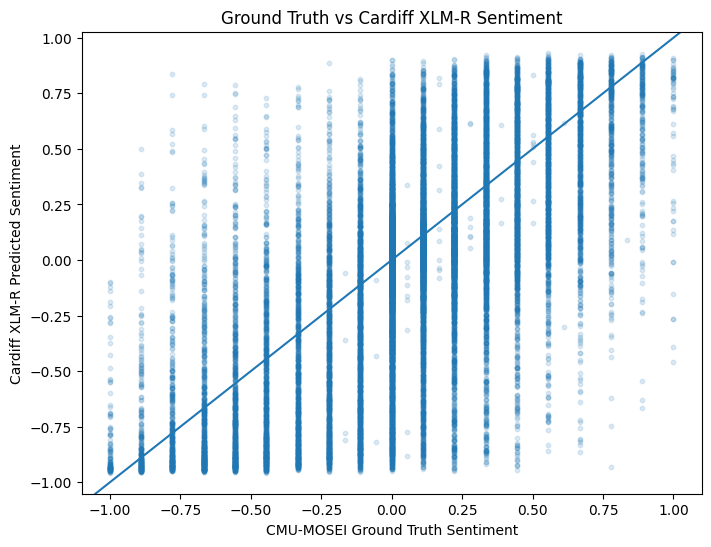

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_true_continuous,
    cardiff_score,
    alpha=0.15,
    s=10
)

plt.xlabel("CMU-MOSEI Ground Truth Sentiment")
plt.ylabel("Cardiff XLM-R Predicted Sentiment")

plt.title(
    "Ground Truth vs Cardiff XLM-R Sentiment"
)

plt.axline(
    (0, 0),
    slope=1
)

plt.show()

In [32]:
sentiment_predictions_df = sentiment_df[
    [
        "segment_id",
        "label_idx",
        "start",
        "end",
        "text",
        "sentiment"
    ]
].copy()

sentiment_predictions_df[
    "sentiment_normalized"
] = y_true_continuous

sentiment_predictions_df[
    "siebert_score"
] = siebert_score

sentiment_predictions_df[
    "cardiff_xlm_score"
] = cardiff_score

sentiment_predictions_df[
    "distilbert_score"
] = distil_score

sentiment_predictions_df[
    "cardiff_abs_error"
] = np.abs(
    y_true_continuous - cardiff_score
)

sentiment_predictions_df[
    "distilbert_abs_error"
] = np.abs(
    y_true_continuous - distil_score
)

sentiment_predictions_df[
    "siebert_abs_error"
] = np.abs(
    y_true_continuous - siebert_score
)

print(
    sentiment_predictions_df.shape
)

(23253, 13)


In [33]:
largest_errors = (
    sentiment_predictions_df
    .sort_values(
        "cardiff_abs_error",
        ascending=False
    )
    .head(20)
)

display(
    largest_errors[
        [
            "text",
            "sentiment",
            "cardiff_xlm_score",
            "cardiff_abs_error"
        ]
    ]
)

,text,sentiment,cardiff_xlm_score,cardiff_abs_error
6118,go watch it i mean i just want everyone to see...,2.333333,-0.929878,1.707656
15265,forth and vocals are definitely pretty on this...,-2.333333,0.835989,1.613767
1537,but live free or die hard basically if you're ...,2.666667,-0.666945,1.555834
6888,my life and let me submit that one of the reas...,2.000000,-0.862784,1.529451
2507,umm it's mostly about this guy named who is a ...,2.333333,-0.748438,1.526216
4697,i highly recommend going to see anything excep...,-2.333333,0.741478,1.519256
11266,you number two it's so easy when you're feelin...,2.666667,-0.629295,1.518184
15652,go they actually stay and lead the prison guar...,2.000000,-0.832006,1.498673
20068,call me corny everyone knows that buying a hom...,2.000000,-0.819496,1.486163
21055,a lot of people they write a beautiful speech ...,2.000000,-0.810446,1.477113


In [34]:
PREDICTIONS_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_model_predictions.pkl"
)

sentiment_predictions_df.to_pickle(
    PREDICTIONS_PATH
)

print("Saved:")
print(PREDICTIONS_PATH)

Saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_model_predictions.pkl


In [35]:
PREDICTIONS_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_model_predictions.pkl"
)

sentiment_predictions_df.to_pickle(
    PREDICTIONS_PATH
)

print("Saved:")
print(PREDICTIONS_PATH)

Saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_model_predictions.pkl


In [36]:
MODEL_METADATA_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_model_metadata.json"
)

metadata = {
    "dataset": "CMU-MOSEI",
    "evaluation_type": "pretrained_zero_shot_evaluation",
    "number_of_samples": int(len(texts)),
    "ground_truth": {
        "source": "CMU-MOSEI sentiment annotation",
        "original_range": [-3, 3],
        "normalized_range": [-1, 1],
        "normalization": "sentiment / 3.0"
    },
    "models": {
        "SiEBERT": SIEBERT_MODEL,
        "Cardiff_XLMR": CARDIFF_XLM_MODEL,
        "Multilingual_DistilBERT": DISTIL_MODEL
    },
    "continuous_score": (
        "P(positive) - P(negative)"
    ),
    "note": (
        "No model was fine-tuned on CMU-MOSEI "
        "during this experiment."
    )
}

with open(
    MODEL_METADATA_PATH,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Saved:")
print(MODEL_METADATA_PATH)

Saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_model_metadata.json


In [38]:
assert len(reloaded_predictions) == 23253

assert (
    reloaded_predictions[
        "cardiff_xlm_score"
    ].notna().all()
)

assert (
    reloaded_predictions[
        "distilbert_score"
    ].notna().all()
)

assert (
    reloaded_predictions[
        "siebert_score"
    ].notna().all()
)

print("Final sentiment prediction artifact validation PASSED.")

Final sentiment prediction artifact validation PASSED.
